In [29]:
import pandas as pd
import requests
import yfinance as yf
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, ccf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
import warnings
warnings.filterwarnings('ignore')

In [30]:
BANXICO_TOKEN = '0c26688000f6b1ceb7ae7852d7f95599a495843728004bcc3f75c962eb17b02c'
SERIE_FIX = 'SF43718'

# Banxico
url = f'https://www.banxico.org.mx/SieAPIRest/service/v1/series/{SERIE_FIX}/datos'
res = requests.get(url, headers={'Bmx-Token': BANXICO_TOKEN})
df_usd = pd.DataFrame(res.json()['bmx']['series'][0]['datos'])
df_usd['fecha'] = pd.to_datetime(df_usd['fecha'], format='%d/%m/%Y')
df_usd['dato'] = pd.to_numeric(df_usd['dato'])
df_usd.set_index('fecha', inplace=True)
df_usd.columns = ['USD_MXN']

# Yahoo Finance (WTI)
df_yf = yf.download('CL=F', start='2023-01-01', progress=False)
if isinstance(df_yf.columns, pd.MultiIndex):
    df_wti = df_yf['Close'].copy()
else:
    df_wti = df_yf[['Close']].copy()
df_wti.columns = ['WTI']

# Unir
df = pd.merge(df_usd, df_wti, left_index=True, right_index=True, how='inner')
df = df.ffill().dropna()

In [31]:
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Scatter(x=df.index, y=df['USD_MXN'], name="USD/MXN", line=dict(color='blue')), secondary_y=False)
fig.add_trace(go.Scatter(x=df.index, y=df['WTI'], name="Petroleo WTI", line=dict(color='red', dash='dot')), secondary_y=True)

fig.update_layout(title_text="Comparacion: Tipo de Cambio vs WTI", hovermode='x unified')
fig.update_yaxes(title_text="Pesos por Dolar", secondary_y=False)
fig.update_yaxes(title_text="USD por Barril", secondary_y=True)
fig.show()

In [32]:
# Calculamos media movil para visualizar la tendencia
df['Media_Movil'] = df['USD_MXN'].rolling(window=20).mean()

fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df['USD_MXN'], name="Original (USD/MXN)", line=dict(color='blue')))
fig.add_trace(go.Scatter(x=df.index, y=df['Media_Movil'], name="Media Movil (20 dias)", line=dict(color='orange')))
fig.update_layout(title="Analisis de Estacionariedad", xaxis_title="Fecha", yaxis_title="Precio")
fig.show()

# Prueba ADF
resultado_adf = adfuller(df['USD_MXN'].dropna())
print(f"Estadistico ADF: {resultado_adf[0]:.4f}, p-value: {resultado_adf[1]:.4f}")

Estadistico ADF: -1.5607, p-value: 0.5033


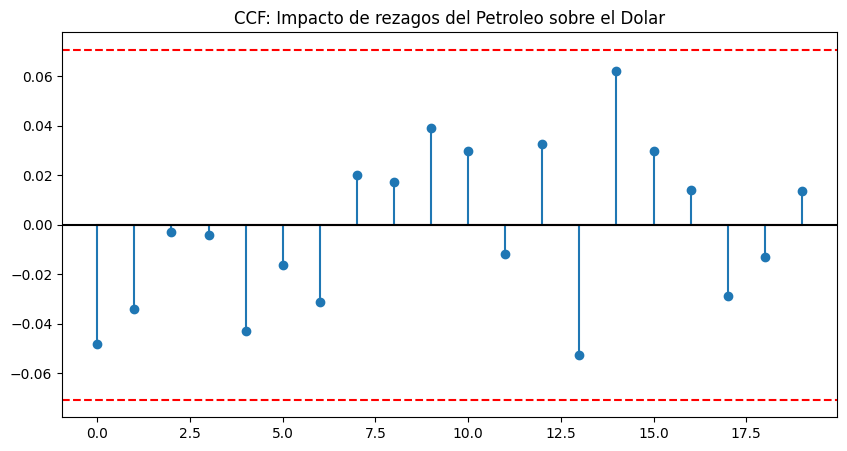

In [33]:
# Diferenciamos para quitar tendencia antes de medir correlacion
diff_usd = df['USD_MXN'].diff().dropna()
diff_wti = df['WTI'].diff().dropna()

ccf_valores = ccf(diff_wti, diff_usd)[:20] # Primeros 20 rezagos
lags = range(20)

fig, ax = plt.subplots(figsize=(10, 5))
ax.stem(lags, ccf_valores)
ax.axhline(0, color='black')
ax.axhline(1.96 / (len(diff_usd)**0.5), color='red', linestyle='--')
ax.axhline(-1.96 / (len(diff_usd)**0.5), color='red', linestyle='--')
ax.set_title("CCF: Impacto de rezagos del Petroleo sobre el Dolar")
plt.show()